In [1]:
import pandas as pd
from pathlib import Path

# Load tallo.csv
data_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv')
df_tallo = pd.read_csv(data_path)

print(f'✓ Loaded: {data_path}')
print(f'\nShape: {df_tallo.shape}')
print(f'\nColumns: {list(df_tallo.columns)}')
print(f'\nFirst 5 rows:')
print(df_tallo.head())
print(f'\nData types:')
print(df_tallo.dtypes)
print(f'\nBasic statistics:')
print(df_tallo.describe())

✓ Loaded: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\tallo.csv

Shape: (498838, 13)

Columns: ['tree_id', 'division', 'family', 'genus', 'species', 'latitude', 'longitude', 'stem_diameter_cm', 'height_m', 'crown_radius_m', 'height_outlier', 'crown_radius_outlier', 'reference_id']

First 5 rows:
  tree_id    division      family   genus           species  latitude  \
0     T_1  Angiosperm  Betulaceae  Betula  Betula pubescens    67.395   
1     T_2  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
2     T_3  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
3     T_4  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   
4     T_5  Gymnosperm    Pinaceae   Picea       Picea abies    67.395   

   longitude  stem_diameter_cm  height_m  crown_radius_m height_outlier  \
0     28.723              10.0       5.6            1.65              N   
1     28.723              10.0       6.6            0.85              N   
2 

In [2]:
# Filter to keep only specific species
species_to_keep = [
    'Fagus sylvatica',
    'Alnus glutinosa',
    'Fraxinus excelsior',
    'Populus nigra',
    'Pinus sylvestris',
    'Larix decidua',
    'Abies alba',
    'Picea abies'
    
]

print(f'Original shape: {df_tallo.shape}')
print(f'\nSpecies in dataset:')
print(df_tallo['species'].value_counts())

# Filter to keep only the specified species
df_tallo = df_tallo[df_tallo['species'].isin(species_to_keep)]

print(f'\n✓ Filtered to keep only specified species')
print(f'New shape: {df_tallo.shape}')
print(f'\nRemaining species:')
print(df_tallo['species'].value_counts())
print(f'\nFirst 5 rows:')
print(df_tallo.head())

Original shape: (498838, 13)

Species in dataset:
species
Quercus ilex               22760
Pinus sylvestris           18221
Pinus halepensis           14003
Pinus pinaster             11766
Quercus infectoria         10964
                           ...  
Lithocarpus orocola            1
Decaspermum parviflorum        1
Terminalia foetidissima        1
Syzygium fastigiatum           1
Tarenna mollis                 1
Name: count, Length: 5163, dtype: int64

✓ Filtered to keep only specified species
New shape: (37693, 13)

Remaining species:
species
Pinus sylvestris      18221
Fagus sylvatica        9470
Picea abies            6723
Fraxinus excelsior     1082
Abies alba             1070
Populus nigra           592
Larix decidua           464
Alnus glutinosa          71
Name: count, dtype: int64

First 5 rows:
  tree_id    division    family  genus           species  latitude  longitude  \
1     T_2  Gymnosperm  Pinaceae  Picea       Picea abies    67.395     28.723   
2     T_3  Gymnosp

In [3]:
# Export filtered dataset
output_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\tallofiltered.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_tallo.to_csv(output_path, index=False)

print(f'✓ Exported to: {output_path}')
print(f'\nFile details:')
print(f'  - Rows: {len(df_tallo):,}')
print(f'  - Columns: {len(df_tallo.columns)}')
print(f'  - Species: {df_tallo["species"].nunique()}')
print(f'\nFile size: {output_path.stat().st_size / 1024 / 1024:.2f} MB')

✓ Exported to: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\tallofiltered.csv

File details:
  - Rows: 37,693
  - Columns: 13
  - Species: 8

File size: 3.03 MB


In [4]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import linregress
import matplotlib.pyplot as plt

# Define allometric model: D = a * H^b
def allometric_model(H, a, b):
    return a * H**b

# Dictionary to store results
allometry_results = {}

print('='*80)
print('D-H ALLOMETRIC RELATIONSHIPS BY SPECIES')
print('='*80)

species_list = sorted(df_tallo['species'].unique())

for species in species_list:
    species_data = df_tallo[df_tallo['species'] == species].copy()
    
    # Remove NaN values
    species_data = species_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    if len(species_data) < 10:  # Skip if not enough data
        continue
    
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    # Fit model using curve_fit
    try:
        popt, pcov = curve_fit(allometric_model, H, D, p0=[1, 0.5], maxfev=5000)
        a, b = popt
        
        # Calculate R-squared using log-linear regression
        H_log = np.log(H)
        D_log = np.log(D)
        slope, intercept, r_value, p_value, std_err = linregress(H_log, D_log)
        r_squared = r_value**2
        
        # Store results
        allometry_results[species] = {
            'a': a,
            'b': b,
            'r_squared': r_squared,
            'n_samples': len(species_data),
            'H_min': H.min(),
            'H_max': H.max(),
            'D_min': D.min(),
            'D_max': D.max()
        }
        
        print(f'\n{species}')
        print(f'  Model: D = {a:.4f} × H^{b:.4f}')
        print(f'  R² = {r_squared:.4f}')
        print(f'  N = {len(species_data):,}')
        print(f'  H range: {H.min():.2f} - {H.max():.2f} m')
        print(f'  D range: {D.min():.2f} - {D.max():.2f} cm')
    
    except Exception as e:
        print(f'\n{species}: Error in fitting - {str(e)}')

print('\n' + '='*80)

D-H ALLOMETRIC RELATIONSHIPS BY SPECIES

Abies alba
  Model: D = 1.0937 × H^1.0885
  R² = 0.8395
  N = 1,070
  H range: 1.50 - 45.80 m
  D range: 1.10 - 113.00 cm

Alnus glutinosa
  Model: D = 1.8516 × H^0.9028
  R² = 0.6086
  N = 71
  H range: 3.50 - 34.00 m
  D range: 5.50 - 80.00 cm

Fagus sylvatica
  Model: D = 1.3980 × H^1.0083
  R² = 0.4059
  N = 8,937
  H range: 2.10 - 55.30 m
  D range: 1.70 - 162.00 cm

Fraxinus excelsior
  Model: D = 0.2672 × H^1.4309
  R² = 0.6966
  N = 1,077
  H range: 1.50 - 47.80 m
  D range: 1.00 - 112.40 cm

Larix decidua
  Model: D = 0.7511 × H^1.2213
  R² = 0.6948
  N = 460
  H range: 4.80 - 44.00 m
  D range: 5.00 - 82.00 cm

Picea abies
  Model: D = 0.7155 × H^1.1862
  R² = 0.8418
  N = 6,690
  H range: 1.40 - 48.60 m
  D range: 1.00 - 109.00 cm

Pinus sylvestris
  Model: D = 4.2424 × H^0.6485
  R² = 0.4654
  N = 17,966
  H range: 1.40 - 41.70 m
  D range: 1.00 - 98.70 cm

Populus nigra
  Model: D = 2.7410 × H^0.7973
  R² = 0.5201
  N = 592
  H rang

✓ Figure saved: DH_Curves_by_Species.png


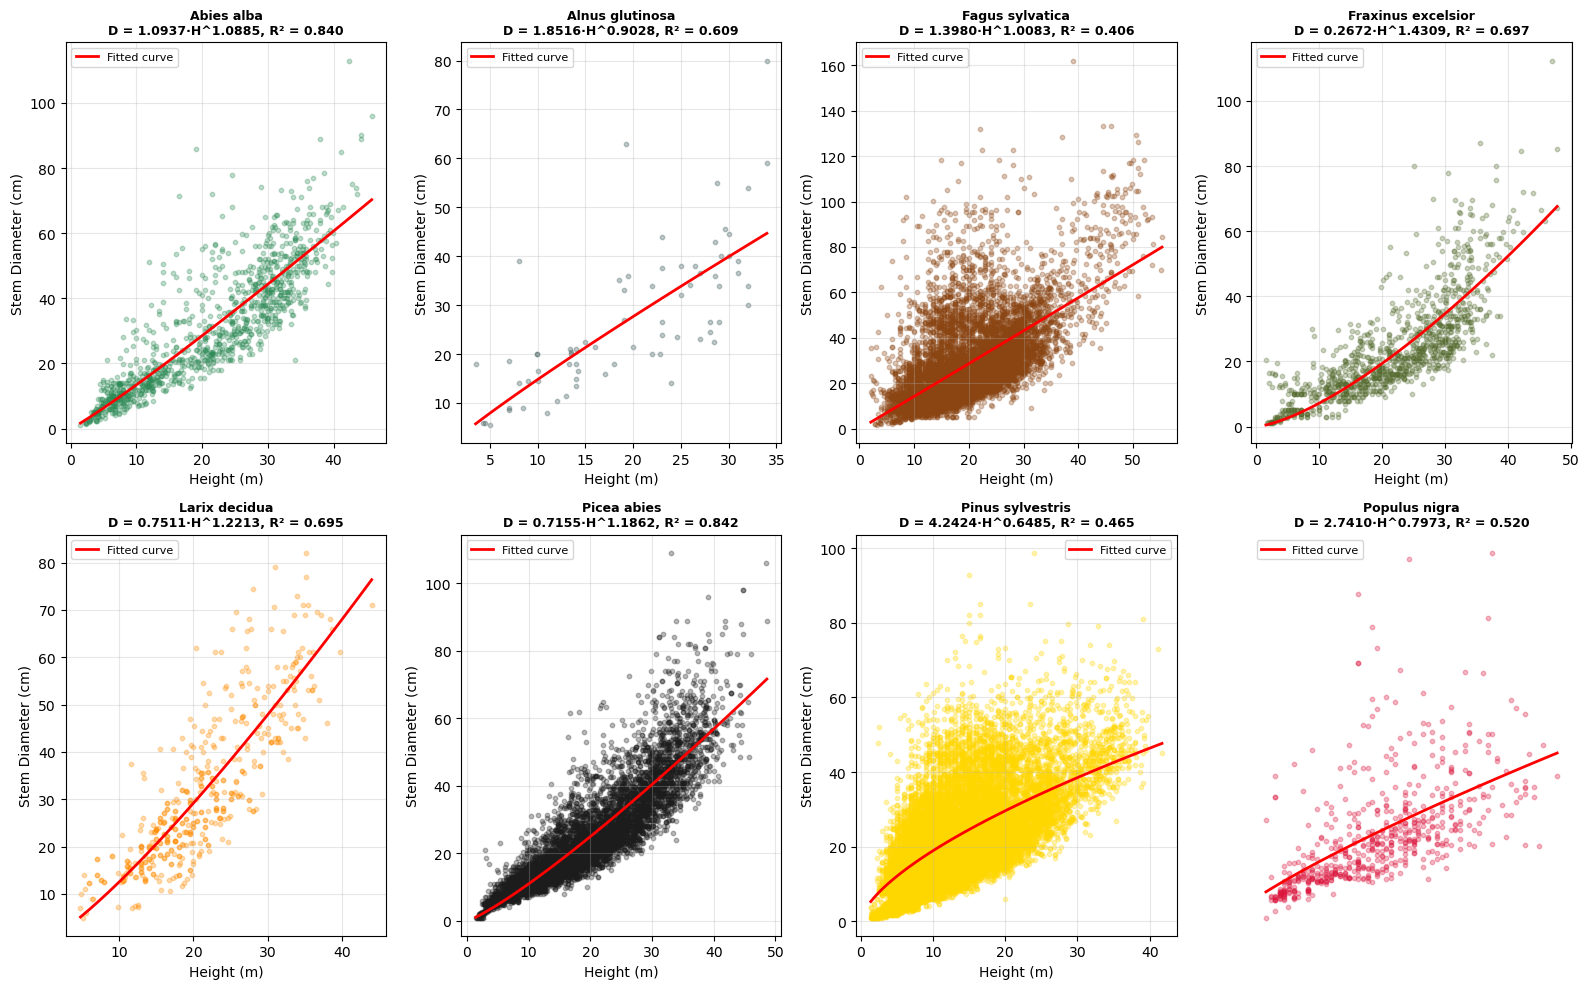

In [5]:
# Create visualization of D-H curves
colors = {
    'Fagus sylvatica': '#8B4513',      # Brown
    'Alnus glutinosa': '#2F4F4F',      # Dark slate gray
    'Fraxinus excelsior': '#556B2F',   # Dark olive green
    'Populus nigra': '#DC143C',        # Crimson
    'Pinus sylvestris': '#FFD700',     # Gold
    'Larix decidua': '#FF8C00',        # Dark orange
    'Abies alba': '#2E8B57',           # Forest green
    'Picea abies': '#1C1C1C'           # Dark charcoal
}

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, species in enumerate(sorted(allometry_results.keys())):
    ax = axes[idx]
    
    species_data = df_tallo[df_tallo['species'] == species].dropna(subset=['stem_diameter_cm', 'height_m'])
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    result = allometry_results[species]
    a, b = result['a'], result['b']
    r_sq = result['r_squared']
    
    # Plot raw data
    ax.scatter(H, D, alpha=0.3, s=10, color=colors.get(species, 'gray'))
    
    # Plot fitted curve
    H_range = np.linspace(H.min(), H.max(), 100)
    D_fitted = allometric_model(H_range, a, b)
    ax.plot(H_range, D_fitted, 'r-', linewidth=2, label=f'Fitted curve')
    
    # Formatting
    ax.set_xlabel('Height (m)', fontsize=10)
    ax.set_ylabel('Stem Diameter (cm)', fontsize=10)
    ax.set_title(f'{species}\nD = {a:.4f}·H^{b:.4f}, R² = {r_sq:.3f}', fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
fig_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\DH_Curves_by_Species.png')
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')

print('✓ Figure saved: DH_Curves_by_Species.png')
plt.show()

In [6]:
# Create summary table
import pandas as pd

summary_data = []
for species, result in sorted(allometry_results.items()):
    summary_data.append({
        'Species': species,
        'Formula': f"D = {result['a']:.4f} × H^{result['b']:.4f}",
        'a': result['a'],
        'b': result['b'],
        'R²': result['r_squared'],
        'N samples': result['n_samples'],
        'H min (m)': result['H_min'],
        'H max (m)': result['H_max'],
        'D min (cm)': result['D_min'],
        'D max (cm)': result['D_max']
    })

summary_df = pd.DataFrame(summary_data)

print('\n' + '='*80)
print('ALLOMETRIC MODEL SUMMARY TABLE')
print('='*80)
print(summary_df.to_string(index=False))

# Export summary to CSV
output_csv = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\AllometricModels_DH.csv')
output_csv.parent.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(output_csv, index=False)
print(f'\n✓ Summary exported to: {output_csv.name}')


ALLOMETRIC MODEL SUMMARY TABLE
           Species               Formula        a        b       R²  N samples  H min (m)  H max (m)  D min (cm)  D max (cm)
        Abies alba D = 1.0937 × H^1.0885 1.093729 1.088502 0.839505       1070        1.5       45.8         1.1       113.0
   Alnus glutinosa D = 1.8516 × H^0.9028 1.851569 0.902750 0.608649         71        3.5       34.0         5.5        80.0
   Fagus sylvatica D = 1.3980 × H^1.0083 1.397982 1.008337 0.405891       8937        2.1       55.3         1.7       162.0
Fraxinus excelsior D = 0.2672 × H^1.4309 0.267167 1.430949 0.696606       1077        1.5       47.8         1.0       112.4
     Larix decidua D = 0.7511 × H^1.2213 0.751140 1.221329 0.694757        460        4.8       44.0         5.0        82.0
       Picea abies D = 0.7155 × H^1.1862 0.715504 1.186179 0.841821       6690        1.4       48.6         1.0       109.0
  Pinus sylvestris D = 4.2424 × H^0.6485 4.242444 0.648462 0.465358      17966        1.4    

In [7]:
# Geographic filtering by latitude and longitude
print('\n' + '='*80)
print('GEOGRAPHIC FILTERING')
print('='*80)

# Define geographic bounds (around Genissiat, France)
lat_min = 41.70
lat_max = 50.70
lon_min = -0.33
lon_max = 12.61

print(f'\nTarget region (Genissiat, France):')
print(f'  Latitude: {lat_min}° to {lat_max}° (reference: 46.2044° ±4.50°)')
print(f'  Longitude: {lon_min}° to {lon_max}° (reference: 6.1432° ±6.47°)')

print(f'\nBefore filtering:')
print(f'  Total records: {len(df_tallo):,}')
print(f'  Lat range: {df_tallo["latitude"].min():.2f}° to {df_tallo["latitude"].max():.2f}°')
print(f'  Lon range: {df_tallo["longitude"].min():.2f}° to {df_tallo["longitude"].max():.2f}°')

# Apply geographic filter
df_tallo_geo = df_tallo[
    (df_tallo['latitude'] >= lat_min) &
    (df_tallo['latitude'] <= lat_max) &
    (df_tallo['longitude'] >= lon_min) &
    (df_tallo['longitude'] <= lon_max)
].copy()

print(f'\nAfter filtering:')
print(f'  Remaining records: {len(df_tallo_geo):,}')
print(f'  Percentage retained: {100*len(df_tallo_geo)/len(df_tallo):.1f}%')
print(f'  Lat range: {df_tallo_geo["latitude"].min():.2f}° to {df_tallo_geo["latitude"].max():.2f}°')
print(f'  Lon range: {df_tallo_geo["longitude"].min():.2f}° to {df_tallo_geo["longitude"].max():.2f}°')

print(f'\nSpecies distribution after geographic filtering:')
print(df_tallo_geo['species'].value_counts().sort_index())

# Update df_tallo with geographic subset
df_tallo = df_tallo_geo.copy()
print(f'\n✓ df_tallo updated with geographic subset')


GEOGRAPHIC FILTERING

Target region (Genissiat, France):
  Latitude: 41.7° to 50.7° (reference: 46.2044° ±4.50°)
  Longitude: -0.33° to 12.61° (reference: 6.1432° ±6.47°)

Before filtering:
  Total records: 37,693
  Lat range: 36.55° to 67.74°
  Lon range: -85.55° to 124.50°

After filtering:
  Remaining records: 11,534
  Percentage retained: 30.6%
  Lat range: 41.70° to 50.55°
  Lon range: -0.33° to 12.00°

Species distribution after geographic filtering:
species
Abies alba             497
Alnus glutinosa         19
Fagus sylvatica       3183
Fraxinus excelsior     431
Larix decidua          229
Picea abies           3289
Pinus sylvestris      3826
Populus nigra           60
Name: count, dtype: int64

✓ df_tallo updated with geographic subset


In [8]:
# Export geographically filtered dataset
output_geo_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\tallofiltered_geographic.csv')
output_geo_path.parent.mkdir(parents=True, exist_ok=True)
df_tallo.to_csv(output_geo_path, index=False)

print(f'\n✓ Geographic filtered dataset exported: {output_geo_path.name}')
print(f'  Records: {len(df_tallo):,}')
print(f'  Columns: {len(df_tallo.columns)}')
print(f'  File size: {output_geo_path.stat().st_size / 1024 / 1024:.2f} MB')


✓ Geographic filtered dataset exported: tallofiltered_geographic.csv
  Records: 11,534
  Columns: 13
  File size: 0.92 MB


In [9]:
# Fit allometric D-H models for GEOGRAPHIC SUBSET
allometry_results_geo = {}

print('\n' + '='*80)
print('D-H ALLOMETRIC RELATIONSHIPS BY SPECIES (GEOGRAPHIC SUBSET - GENISSIAT REGION)')
print('='*80)

species_list_geo = sorted(df_tallo['species'].unique())

for species in species_list_geo:
    species_data = df_tallo[df_tallo['species'] == species].copy()
    
    # Remove NaN values
    species_data = species_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    if len(species_data) < 10:  # Skip if not enough data
        continue
    
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    # Fit model using curve_fit
    try:
        popt, pcov = curve_fit(allometric_model, H, D, p0=[1, 0.5], maxfev=5000)
        a, b = popt
        
        # Calculate R-squared using log-linear regression
        H_log = np.log(H)
        D_log = np.log(D)
        slope, intercept, r_value, p_value, std_err = linregress(H_log, D_log)
        r_squared = r_value**2
        
        # Store results
        allometry_results_geo[species] = {
            'a': a,
            'b': b,
            'r_squared': r_squared,
            'n_samples': len(species_data),
            'H_min': H.min(),
            'H_max': H.max(),
            'D_min': D.min(),
            'D_max': D.max()
        }
        
        print(f'\n{species}')
        print(f'  Model: D = {a:.4f} × H^{b:.4f}')
        print(f'  R² = {r_squared:.4f}')
        print(f'  N = {len(species_data):,}')
        print(f'  H range: {H.min():.2f} - {H.max():.2f} m')
        print(f'  D range: {D.min():.2f} - {D.max():.2f} cm')
    
    except Exception as e:
        print(f'\n{species}: Error in fitting - {str(e)}')

print('\n' + '='*80)


D-H ALLOMETRIC RELATIONSHIPS BY SPECIES (GEOGRAPHIC SUBSET - GENISSIAT REGION)

Abies alba
  Model: D = 1.7536 × H^0.9681
  R² = 0.7910
  N = 497
  H range: 3.10 - 45.80 m
  D range: 5.00 - 113.00 cm

Alnus glutinosa
  Model: D = 0.9629 × H^1.1192
  R² = 0.7923
  N = 19
  H range: 4.30 - 26.00 m
  D range: 5.50 - 35.20 cm

Fagus sylvatica
  Model: D = 1.1189 × H^1.0419
  R² = 0.4131
  N = 2,804
  H range: 2.10 - 43.90 m
  D range: 2.90 - 118.10 cm

Fraxinus excelsior
  Model: D = 0.5496 × H^1.2216
  R² = 0.4405
  N = 428
  H range: 1.50 - 45.80 m
  D range: 10.00 - 87.10 cm

Larix decidua
  Model: D = 2.1761 × H^0.9250
  R² = 0.7905
  N = 225
  H range: 4.80 - 44.00 m
  D range: 5.00 - 82.00 cm

Picea abies
  Model: D = 0.7688 × H^1.1792
  R² = 0.8639
  N = 3,274
  H range: 2.10 - 48.60 m
  D range: 1.80 - 109.00 cm

Pinus sylvestris
  Model: D = 6.5203 × H^0.5420
  R² = 0.4025
  N = 3,653
  H range: 1.40 - 37.90 m
  D range: 1.50 - 82.10 cm

Populus nigra
  Model: D = 6.5047 × H^0.52

✓ Figure saved: DH_Curves_Geographic_Subset.png


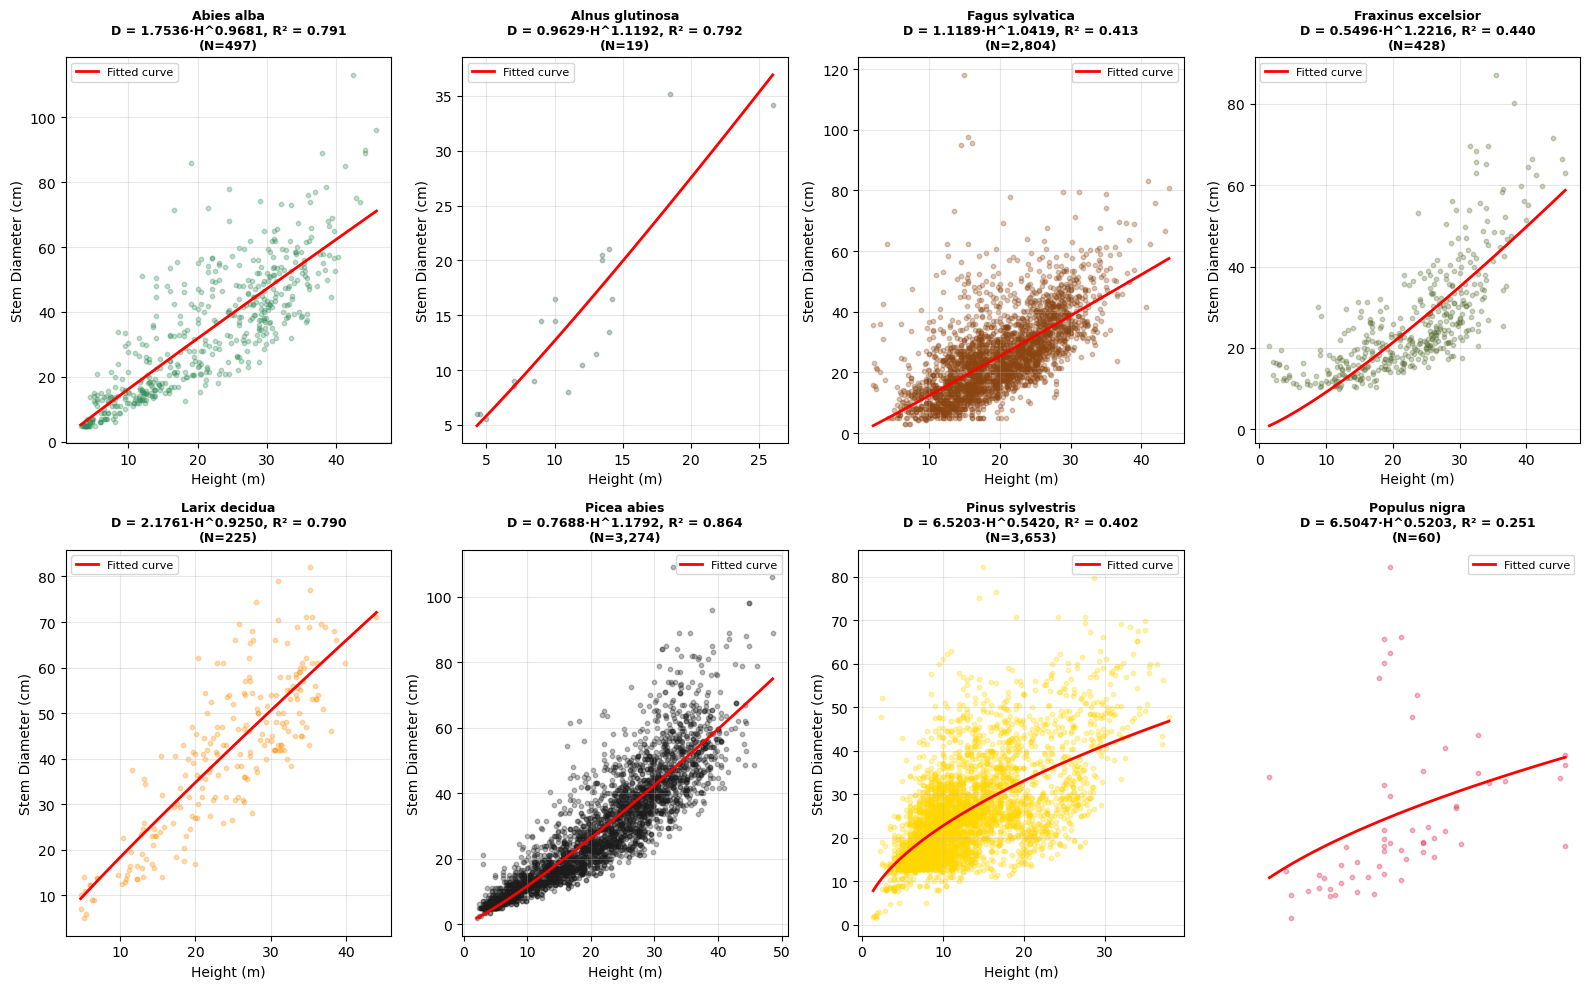

In [10]:
# Visualize D-H curves for geographic subset
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, species in enumerate(sorted(allometry_results_geo.keys())):
    ax = axes[idx]
    
    species_data = df_tallo[df_tallo['species'] == species].dropna(subset=['stem_diameter_cm', 'height_m'])
    H = species_data['height_m'].values
    D = species_data['stem_diameter_cm'].values
    
    result = allometry_results_geo[species]
    a, b = result['a'], result['b']
    r_sq = result['r_squared']
    
    # Plot raw data
    ax.scatter(H, D, alpha=0.3, s=10, color=colors.get(species, 'gray'))
    
    # Plot fitted curve
    H_range = np.linspace(H.min(), H.max(), 100)
    D_fitted = allometric_model(H_range, a, b)
    ax.plot(H_range, D_fitted, 'r-', linewidth=2, label=f'Fitted curve')
    
    # Formatting
    ax.set_xlabel('Height (m)', fontsize=10)
    ax.set_ylabel('Stem Diameter (cm)', fontsize=10)
    ax.set_title(f'{species}\nD = {a:.4f}·H^{b:.4f}, R² = {r_sq:.3f}\n(N={result["n_samples"]:,})', 
                 fontsize=9, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Hide unused subplot
axes[-1].axis('off')

plt.tight_layout()
fig_path_geo = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\DH_Curves_Geographic_Subset.png')
fig_path_geo.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path_geo, dpi=300, bbox_inches='tight')
print('✓ Figure saved: DH_Curves_Geographic_Subset.png')
plt.show()

In [11]:
# Create summary table for GEOGRAPHIC SUBSET
summary_data_geo = []
for species, result in sorted(allometry_results_geo.items()):
    summary_data_geo.append({
        'Species': species,
        'Formula': f"D = {result['a']:.4f} × H^{result['b']:.4f}",
        'a': result['a'],
        'b': result['b'],
        'R²': result['r_squared'],
        'N samples': result['n_samples'],
        'H min (m)': result['H_min'],
        'H max (m)': result['H_max'],
        'D min (cm)': result['D_min'],
        'D max (cm)': result['D_max']
    })

summary_df_geo = pd.DataFrame(summary_data_geo)

print('\n' + '='*80)
print('ALLOMETRIC MODEL SUMMARY TABLE (GEOGRAPHIC SUBSET - GENISSIAT REGION)')
print('='*80)
print(summary_df_geo.to_string(index=False))

# Export summary to CSV
output_csv_geo = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\AllometricModels_DH_Geographic.csv')
output_csv_geo.parent.mkdir(parents=True, exist_ok=True)
summary_df_geo.to_csv(output_csv_geo, index=False)
print(f'\n✓ Summary exported to: {output_csv_geo.name}')
print(f'\n✓ Analysis complete with {len(allometry_results_geo)} species from the Genissiat region')


ALLOMETRIC MODEL SUMMARY TABLE (GEOGRAPHIC SUBSET - GENISSIAT REGION)
           Species               Formula        a        b       R²  N samples  H min (m)  H max (m)  D min (cm)  D max (cm)
        Abies alba D = 1.7536 × H^0.9681 1.753646 0.968082 0.791042        497        3.1       45.8         5.0       113.0
   Alnus glutinosa D = 0.9629 × H^1.1192 0.962907 1.119161 0.792336         19        4.3       26.0         5.5        35.2
   Fagus sylvatica D = 1.1189 × H^1.0419 1.118884 1.041920 0.413102       2804        2.1       43.9         2.9       118.1
Fraxinus excelsior D = 0.5496 × H^1.2216 0.549650 1.221618 0.440484        428        1.5       45.8        10.0        87.1
     Larix decidua D = 2.1761 × H^0.9250 2.176086 0.925047 0.790472        225        4.8       44.0         5.0        82.0
       Picea abies D = 0.7688 × H^1.1792 0.768795 1.179242 0.863937       3274        2.1       48.6         1.8       109.0
  Pinus sylvestris D = 6.5203 × H^0.5420 6.520274 0.54

In [12]:
# Extract D-H pairs using median values from actual data in specified diameter ranges
# Define diameter classes with their ranges
diameter_classes = {
    'D10-20': (10, 20),
    'D20-30': (20, 30),
    'D30-40': (30, 40),
    'D40-50': (40, 50),
    'D50+': (50, np.inf)
}

print('\n' + '='*80)
print('DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER RANGES')
print('='*80)
print('Method: Calculate median D and H from actual data in specified ranges')
print('(Instead of using inverse allometric curves)\n')

# Create result dictionary
dh_pairs = {}

for species in sorted(allometry_results_geo.keys()):
    print(f'\n{species}:')
    species_pairs = {'Species': species}
    species_data = df_tallo[df_tallo['species'] == species].copy()
    
    # Remove NaN values
    species_data = species_data.dropna(subset=['stem_diameter_cm', 'height_m'])
    
    print(f'  Total samples for this species: {len(species_data):,}')
    
    for d_class, (d_min, d_max) in diameter_classes.items():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        
        # Filter data within the diameter range
        if d_max == np.inf:
            data_in_range = species_data[species_data['stem_diameter_cm'] >= d_min]
            range_str = f'>= {d_min} cm'
        else:
            data_in_range = species_data[
                (species_data['stem_diameter_cm'] >= d_min) & 
                (species_data['stem_diameter_cm'] < d_max)
            ]
            range_str = f'{d_min}-{d_max} cm'
        
        if len(data_in_range) > 0:
            # Calculate medians
            d_median = data_in_range['stem_diameter_cm'].median()
            h_median = data_in_range['height_m'].median()
            n_samples = len(data_in_range)
            
            species_pairs[col_d] = round(d_median, 2)
            species_pairs[col_h] = round(h_median, 2)
            
            print(f'  {d_class} ({range_str}): D_median={d_median:.2f} cm, H_median={h_median:.2f} m (n={n_samples:,})')
        else:
            # No data in this range
            species_pairs[col_d] = np.nan
            species_pairs[col_h] = np.nan
            print(f'  {d_class} ({range_str}): NA (no data in range)')
    
    dh_pairs[species] = species_pairs

print('\n' + '='*80)

# Create DataFrame
dh_df = pd.DataFrame([dh_pairs[sp] for sp in sorted(dh_pairs.keys())])

# Reorder columns for better readability
col_order = ['Species']
for d_class in diameter_classes.keys():
    col_order.extend([d_class, d_class.replace('D', 'H')])
dh_df = dh_df[col_order]

print('\nD-H PAIRS TABLE (Median values from actual data by diameter range):')
print('='*80)
print(dh_df.to_string(index=False))

# Export to CSV
output_dh = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\DH_Pairs_DiameterRanges.csv')
output_dh.parent.mkdir(parents=True, exist_ok=True)
dh_df.to_csv(output_dh, index=False)
print(f'\n✓ Exported to: {output_dh.name}')


DIAMETER-HEIGHT PAIRS AT SPECIFIC DIAMETER RANGES
Method: Calculate median D and H from actual data in specified ranges
(Instead of using inverse allometric curves)


Abies alba:
  Total samples for this species: 497
  D10-20 (10-20 cm): D_median=14.50 cm, H_median=11.70 m (n=107)
  D20-30 (20-30 cm): D_median=24.00 cm, H_median=19.10 m (n=73)
  D30-40 (30-40 cm): D_median=35.00 cm, H_median=26.90 m (n=81)
  D40-50 (40-50 cm): D_median=44.55 cm, H_median=28.50 m (n=84)
  D50+ (>= 50 cm): D_median=57.00 cm, H_median=32.50 m (n=105)

Alnus glutinosa:
  Total samples for this species: 19
  D10-20 (10-20 cm): D_median=14.50 cm, H_median=12.00 m (n=7)
  D20-30 (20-30 cm): D_median=20.50 cm, H_median=13.50 m (n=3)
  D30-40 (30-40 cm): D_median=34.70 cm, H_median=22.25 m (n=2)
  D40-50 (40-50 cm): NA (no data in range)
  D50+ (>= 50 cm): NA (no data in range)

Fagus sylvatica:
  Total samples for this species: 2,804
  D10-20 (10-20 cm): D_median=15.10 cm, H_median=15.80 m (n=803)
  D20-30 (2

In [21]:
import math

# Define VEF equation constants by species
vef_constants = {
    'Abies alba': {'b2': 1.496, 'b4': 0.566, 'G': 0},
    'Fagus sylvatica': {'b2': 0.842, 'b4': 0.627, 'G': 1},
    'Fraxinus excelsior': {'b2': 1.112, 'b4': 0.470, 'G': 1},
    'Larix decidua': {'b2': 0.966, 'b4': 0.454, 'G': 0},
    'Pinus sylvestris': {'b2': 0.566, 'b4': 0.336, 'G': 0},
    'Picea abies': {'b2': 0.953, 'b4': 0.473, 'G': 0},
    'Alnus glutinosa': {'b2': 1.015, 'b4': 0.522, 'G': 1},
    'Populus nigra': {'b2': 1.015, 'b4': 0.522, 'G': 1}
}

# Define VEF calculation function
def calculate_vef(DBH_cm, H_m, b2, b4, G):
    """
    Calculate VEF (Form Factor) using the equation:
    VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1
    """
    if pd.isna(DBH_cm) or pd.isna(H_m):
        return np.nan
    
    try:
        term1 = math.exp(-6.830 * (DBH_cm / 100.0)) / b2
        term2 = math.exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2))
        vef = term1 + term2 + 1
        return vef
    except Exception as e:
        return np.nan

# Define diameter ranges
diameter_classes = {
    'D10-20': 'VEF10-20',
    'D20-30': 'VEF20-30',
    'D30-40': 'VEF30-40',
    'D40-50': 'VEF40-50',
    'D50+': 'VEF50+'
}

print('\n' + '='*100)
print('VEF (FORM FACTOR) CALCULATIONS BY DIAMETER RANGE')
print('='*100)
print('Equation: VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1\n')

# Create result dataframe
vef_df = dh_df[['Species']].copy()

# Calculate VEF for each diameter range
for d_class, vef_col in diameter_classes.items():
    col_d = d_class
    col_h = d_class.replace('D', 'H')
    
    vef_df[vef_col] = np.nan
    
    for idx, row in dh_df.iterrows():
        species = row['Species']
        
        # Skip if species not in constants
        if species not in vef_constants:
            print(f'⚠ {species}: No VEF constants defined')
            continue
        
        D = row[col_d]
        H = row[col_h]
        
        if pd.notna(D) and pd.notna(H):
            # Get species constants
            constants = vef_constants[species]
            b2 = constants['b2']
            b4 = constants['b4']
            G = constants['G']
            
            # Calculate VEF
            vef_value = calculate_vef(D, H, b2, b4, G)
            vef_df.at[idx, vef_col] = round(vef_value, 6) if pd.notna(vef_value) else np.nan

print('\n' + '='*100)
print('VEF SUMMARY TABLE (by diameter range)')
print('='*100)

# Display with better formatting
print(vef_df.to_string(index=False))

# Export to CSV
output_vef = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\VEF_DiameterRanges.csv')
output_vef.parent.mkdir(parents=True, exist_ok=True)
vef_df.to_csv(output_vef, index=False)

print(f'\n✓ Exported to: {output_vef.name}')
print(f'  Location: {output_vef.parent}')
print(f'  Rows: {len(vef_df)}')
print(f'  Columns: {list(vef_df.columns)}')


VEF (FORM FACTOR) CALCULATIONS BY DIAMETER RANGE
Equation: VEF = exp(-6.830 * (DBH_cm / 100.0)) / b2 + exp(1.009 * G + b4) * (DBH_cm / (H_m ** 2)) + 1


VEF SUMMARY TABLE (by diameter range)
           Species  VEF10-20  VEF20-30  VEF30-40  VEF40-50   VEF50+
   Alnus glutinosa  1.831447  1.762902  1.416120       NaN      NaN
   Fagus sylvatica  1.734012  1.522163  1.389204  1.361956 1.361879
Fraxinus excelsior  1.602966  1.338148  1.273444  1.236703 1.218199
     Larix decidua  1.562291  1.323433  1.205045  1.137381 1.107244
       Picea abies  1.519118  1.286026  1.174890  1.127382 1.098687
  Pinus sylvestris  1.906523  1.568277  1.387611  1.257064 1.165967
     Populus nigra  1.803696  1.483975  1.397427  1.412915 1.983559

✓ Exported to: VEF_DiameterRanges.csv
  Location: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry
  Rows: 7
  Columns: ['Species', 'VEF10-20', 'VEF20-30', 'VEF30-40', 'VEF40-50', 'VEF50+']


In [13]:
# Calculate volume for each species using provided equations - TEMPORARY (skip CSV export)
print('\n' + '='*80)
print('VOLUME CALCULATIONS USING SPECIES-SPECIFIC EQUATIONS')
print('='*80)

# Define diameter classes
diameter_classes = {
    'D10-20': (10, 20),
    'D20-30': (20, 30),
    'D30-40': (30, 40),
    'D40-50': (40, 50),
    'D50+': (50, np.inf)
}

# Define volume equations for each species
volume_equations = {
    'Fagus sylvatica': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.049, 'b': 1.78189, 'c': 1.08345},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Alnus glutinosa': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Fraxinus excelsior': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H + d*D*(H^2) + e*(H^2) (result in dm³)',
        'params': {'a': -1.86827, 'b': 0.21461, 'c': 0.01283, 'd': 0.01380, 'e': -0.06311},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H + p['d']*D*(H**2) + p['e']*(H**2)) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Populus nigra': {
        'model': 'V = a + b*(D^2)*H (result in dm³)',
        'params': {'a': 9.69, 'b': 0.0365},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },
    'Pinus sylvestris': {
        'model': 'V = a + b*(D^2) + c*(D^2)*H (result in dm³)',
        'params': {'a': 8.6524, 'b': 0.07684, 'c': 0.03157},
        'func': lambda D, H, p: (p['a'] + p['b']*(D**2) + p['c']*(D**2)*H) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    },

    'Larix decidua': {
        'model': 'V = a*(D^b)*(H^c) (result in dm³)',
        'params': {'a': 0.0983, 'b': 1.551, 'c': 1.1483},
        'func': lambda D, H, p: (p['a'] * (D**p['b']) * (H**p['c'])) / 1000 if pd.notna(D) and pd.notna(H) else np.nan
    }
}

# Add volume columns to dh_df
for d_class in diameter_classes.keys():
    col_v = d_class.replace('D', 'V')
    dh_df[col_v] = np.nan

# Calculate volumes for each species
for idx, row in dh_df.iterrows():
    species = row['Species']
    if species not in volume_equations:
        print(f'⚠ {species}: No equation defined')
        continue
    
    eq = volume_equations[species]
    print(f'\n{species}')
    
    for d_class in diameter_classes.keys():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        col_v = d_class.replace('D', 'V')
        
        d_val = row[col_d]
        h_val = row[col_h]
        
        if pd.notna(h_val):
            v_val = eq['func'](d_val, h_val, eq['params'])
            dh_df.at[idx, col_v] = round(v_val, 4)
            print(f'  {col_v}: D={d_val}, H={h_val:.2f} → V={v_val:.4f} m³')

print(f'\n✓ Volume calculations complete')


VOLUME CALCULATIONS USING SPECIES-SPECIFIC EQUATIONS
⚠ Abies alba: No equation defined

Alnus glutinosa
  V10-20: D=14.5, H=12.00 → V=0.1045 m³
  V20-30: D=20.5, H=13.50 → V=0.2201 m³
  V30-40: D=34.7, H=22.25 → V=0.9470 m³

Fagus sylvatica
  V10-20: D=15.1, H=15.80 → V=0.1229 m³
  V20-30: D=24.5, H=20.50 → V=0.3862 m³
  V30-40: D=34.1, H=25.30 → V=0.8742 m³
  V40-50: D=44.0, H=27.30 → V=1.4951 m³
  V50+: D=55.7, H=29.20 → V=2.4479 m³

Fraxinus excelsior
  V10-20: D=15.35, H=15.30 → V=0.1298 m³
  V20-30: D=23.7, H=25.50 → V=0.4741 m³
  V30-40: D=33.6, H=28.40 → V=0.9749 m³
  V40-50: D=44.45, H=31.75 → V=1.7817 m³
  V50+: D=59.8, H=35.95 → V=3.4000 m³

Larix decidua
  V10-20: D=14.25, H=11.45 → V=0.0995 m³
  V20-30: D=24.75, H=17.15 → V=0.3726 m³
  V30-40: D=35.5, H=22.20 → V=0.8769 m³
  V40-50: D=43.5, H=28.50 → V=1.6012 m³
  V50+: D=58.0, H=32.30 → V=2.8883 m³
⚠ Picea abies: No equation defined

Pinus sylvestris
  V10-20: D=15.8, H=8.50 → V=0.0948 m³
  V20-30: D=24.6, H=12.00 → V=0.2

In [14]:
# Display summary table with volumes
print('\n' + '='*80)
print('VOLUME SUMMARY TABLE (D-H-V)')
print('='*80)

# Display with better formatting
display_df = dh_df.copy()

# Round numeric columns for display
for col in display_df.columns:
    if col != 'Species':
        display_df[col] = display_df[col].apply(lambda x: f'{x:.2f}' if pd.notna(x) else 'NA')

print(display_df.to_string(index=False))
print(f'\n✓ File saved: DHV_DiameterRanges.csv')
print(f'\n✓ Calculations complete!')
print(f'  - 7 species with diameter-height-volume relationships')
print(f'  - 5 diameter ranges per species (10-20, 20-30, 30-40, 40-50, 50+ cm)')
print(f'  - Volumes in m³')


VOLUME SUMMARY TABLE (D-H-V)
           Species D10-20 H10-20 D20-30 H20-30 D30-40 H30-40 D40-50 H40-50  D50+  H50+ V10-20 V20-30 V30-40 V40-50 V50+
        Abies alba  14.50  11.70  24.00  19.10  35.00  26.90  44.55  28.50 57.00 32.50     NA     NA     NA     NA   NA
   Alnus glutinosa  14.50  12.00  20.50  13.50  34.70  22.25     NA     NA    NA    NA   0.10   0.22   0.95     NA   NA
   Fagus sylvatica  15.10  15.80  24.50  20.50  34.10  25.30  44.00  27.30 55.70 29.20   0.12   0.39   0.87   1.50 2.45
Fraxinus excelsior  15.35  15.30  23.70  25.50  33.60  28.40  44.45  31.75 59.80 35.95   0.13   0.47   0.97   1.78 3.40
     Larix decidua  14.25  11.45  24.75  17.15  35.50  22.20  43.50  28.50 58.00 32.30   0.10   0.37   0.88   1.60 2.89
       Picea abies  15.00  13.00  24.50  21.00  35.00  26.70  44.00  30.60 57.00 34.40     NA     NA     NA     NA   NA
  Pinus sylvestris  15.80   8.50  24.60  12.00  33.50  15.00  44.50  19.00 56.00 24.80   0.09   0.28   0.63   1.35 2.70
     Popul

In [15]:
# Calculate shape factors (f) for original volumes - with sp_Index column
print('\n' + '='*80)
print('SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS')
print('='*80)
print('Formula: f = V / ((π/4) * D² * H)')
print('f represents the ratio of actual volume to ideal cylinder volume\n')

# Define diameter ranges and their corresponding shape factor column names
diameter_classes_f = {
    'D10-20': 'f10-20',
    'D20-30': 'f20-30',
    'D30-40': 'f30-40',
    'D40-50': 'f40-50',
    'D50+': 'f50+'
}

# Mapping: Species → sp_Index (Abies alba removed)
species_to_sp_index = {
    'Fagus sylvatica': 'sp_6',
    'Alnus glutinosa': 'sp_4',
    'Fraxinus excelsior': 'sp_5',
    'Populus nigra': 'sp_2',
    'Pinus sylvestris': 'sp_11',
    'Larix decidua': 'sp_10'
}

# Create DataFrame for shape factors with sp_Index
dh_df_f = pd.DataFrame()
dh_df_f['sp_Index'] = [species_to_sp_index.get(sp, 'sp_?') for sp in dh_df['Species']]
dh_df_f['Species'] = dh_df['Species']

# Add the shape factor columns
for d_class, f_col_name in diameter_classes_f.items():
    dh_df_f[f_col_name] = np.nan

# Calculate shape factors for each species
for idx, row in dh_df.iterrows():
    species = row['Species']
    print(f'\n{species}:')
    
    for d_class, f_col_name in diameter_classes_f.items():
        col_d = d_class
        col_h = d_class.replace('D', 'H')
        col_v = d_class.replace('D', 'V')
        
        d_val = row[col_d]
        h_val = row[col_h]
        v_val = row[col_v]
        
        if pd.notna(d_val) and pd.notna(h_val) and pd.notna(v_val):
            # Convert D from cm to m
            d_m = d_val / 100  # Convert cm to m
            # Calculate cylinder volume: (π/4) * D² * H (in m³)
            v_cylinder = (np.pi / 4) * (d_m**2) * h_val  # m³
            
            # Calculate shape factor
            f_val = v_val / v_cylinder
            dh_df_f.at[idx, f_col_name] = round(f_val, 5)
            print(f'  {d_class} ({f_col_name}): V={v_val:.4f} m³ / V_cyl={v_cylinder:.4f} m³ → f={f_val:.5f}')
        else:
            dh_df_f.at[idx, f_col_name] = np.nan
            print(f'  {d_class} ({f_col_name}): NA (missing D, H, or V values)')

print('\n' + '='*80)
print('\nSHAPE FACTORS TABLE (Before adding conifers average):')
print('='*80)
print(dh_df_f.to_string(index=False))

# Now add rows for conifers (sp_1 and sp_12) as average of Pinus sylvestris and Larix decidua
print('\n' + '='*80)
print('CALCULATING CONIFERS AVERAGE (Pinus sylvestris + Larix decidua)')
print('='*80)

# Find indices for Pinus and Larix
pinus_idx = dh_df_f[dh_df_f['Species'] == 'Pinus sylvestris'].index
larix_idx = dh_df_f[dh_df_f['Species'] == 'Larix decidua'].index

if len(pinus_idx) > 0 and len(larix_idx) > 0:
    pinus_idx = pinus_idx[0]
    larix_idx = larix_idx[0]
    
    # Calculate average shape factors
    conifers_row = {'sp_Index': 'sp_1', 'Species': 'conifers'}
    
    for f_col_name in diameter_classes_f.values():
        pinus_f = dh_df_f.at[pinus_idx, f_col_name]
        larix_f = dh_df_f.at[larix_idx, f_col_name]
        
        if pd.notna(pinus_f) and pd.notna(larix_f):
            avg_f = round((pinus_f + larix_f) / 2, 5)
            conifers_row[f_col_name] = avg_f
            print(f'{f_col_name}: ({pinus_f:.5f} + {larix_f:.5f}) / 2 = {avg_f:.5f}')
        else:
            conifers_row[f_col_name] = np.nan
    
    # Add row for sp_1 (conifers)
    dh_df_f = pd.concat([dh_df_f, pd.DataFrame([conifers_row])], ignore_index=True)
    
    # Add row for sp_12 (conifers - identical to sp_1)
    conifers_row_sp12 = conifers_row.copy()
    conifers_row_sp12['sp_Index'] = 'sp_12'
    dh_df_f = pd.concat([dh_df_f, pd.DataFrame([conifers_row_sp12])], ignore_index=True)
    
    print(f'\n✓ Added sp_1 (conifers) and sp_12 (conifers) with averaged values')

print('\n' + '='*80)
print('\nFINAL SHAPE FACTORS TABLE (diameter ranges: 10-20, 20-30, 30-40, 40-50, 50+ cm):')
print('='*80)
print(dh_df_f.to_string(index=False))

# Export shape factors to CSV - ShapeFactors_Original.csv
output_factors = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\ShapeFactors_Original.csv')
output_factors.parent.mkdir(parents=True, exist_ok=True)
dh_df_f.to_csv(output_factors, index=False)
print(f'\n✓ Exported to: {output_factors.name}')
print(f'  Rows: {len(dh_df_f)} (7 species + 2 conifers)')
print(f'  Columns: {list(dh_df_f.columns)}')


SHAPE FACTORS (f) FOR ORIGINAL VOLUME EQUATIONS
Formula: f = V / ((π/4) * D² * H)
f represents the ratio of actual volume to ideal cylinder volume


Abies alba:
  D10-20 (f10-20): NA (missing D, H, or V values)
  D20-30 (f20-30): NA (missing D, H, or V values)
  D30-40 (f30-40): NA (missing D, H, or V values)
  D40-50 (f40-50): NA (missing D, H, or V values)
  D50+ (f50+): NA (missing D, H, or V values)

Alnus glutinosa:
  D10-20 (f10-20): V=0.1045 m³ / V_cyl=0.1982 m³ → f=0.52736
  D20-30 (f20-30): V=0.2201 m³ / V_cyl=0.4456 m³ → f=0.49396
  D30-40 (f30-40): V=0.9470 m³ / V_cyl=2.1042 m³ → f=0.45006
  D40-50 (f40-50): NA (missing D, H, or V values)
  D50+ (f50+): NA (missing D, H, or V values)

Fagus sylvatica:
  D10-20 (f10-20): V=0.1229 m³ / V_cyl=0.2829 m³ → f=0.43436
  D20-30 (f20-30): V=0.3862 m³ / V_cyl=0.9664 m³ → f=0.39961
  D30-40 (f30-40): V=0.8742 m³ / V_cyl=2.3106 m³ → f=0.37835
  D40-50 (f40-50): V=1.4951 m³ / V_cyl=4.1510 m³ → f=0.36017
  D50+ (f50+): V=2.4479 m³ / V_cy


✓ Exported to: ShapeFactors_Original.csv
  Rows: 10 (7 species + 2 conifers)
  Columns: ['sp_Index', 'Species', 'f10-20', 'f20-30', 'f30-40', 'f40-50', 'f50+']


In [16]:
# Remove Abies alba from analysis
dh_df = dh_df[dh_df['Species'] != 'Abies alba'].reset_index(drop=True)
print('✓ Abies alba removed from analysis')
print(f'Remaining species: {list(dh_df["Species"].unique())}')

✓ Abies alba removed from analysis
Remaining species: ['Alnus glutinosa', 'Fagus sylvatica', 'Fraxinus excelsior', 'Larix decidua', 'Picea abies', 'Pinus sylvestris', 'Populus nigra']


In [17]:
# Load DefinitiveRV4 dataset for relating shape factors
print('\n' + '='*80)
print('LOADING DEFINITIVE RV4 DATA WITH CONIFERS')
print('='*80)

definitive_rv4_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\DefinitiveRV4(withconifers).csv')
df_rv4 = pd.read_csv(definitive_rv4_path)

print(f'\n✓ Data loaded successfully from: {definitive_rv4_path}')
print(f'\nShape: {df_rv4.shape}')
print(f'\nColumns:')
for i, col in enumerate(df_rv4.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nFirst 5 rows:')
print(df_rv4.head())

print(f'\nData types:')
print(df_rv4.dtypes)

print(f'\nBasic statistics:')
print(df_rv4.describe())


LOADING DEFINITIVE RV4 DATA WITH CONIFERS

✓ Data loaded successfully from: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\DefinitiveRV4(withconifers).csv

Shape: (89, 153)

Columns:
   1. Id_Data
   2. Id_Place
   3. Basin
   4. Sub_Basin
   5. Stand_Code
   6. Bank
   7. Cod_Plg
   8. Standing_Dead_Trees
   9. Dead_Wood
  10. Regeneration
  11. Lat_Connectivity
  12. LW_Presence
  13. Lentgh (m)
  14. Distance (m)
  15. Sinuosity
  16. Sinuosity 1.1 y 1.4
  17. Gradient (m)
  18. Gradient (%)
  19. Gradient (class) (0.2%,2%)
  20. Width_classes
  21. Width_Mean
  22. Width_error
  23. Width/Height
  24. Flow Acc (m)
  25. SPI (b0.5)
  26. SPI / Width
  27. SPI * Width/Height
  28. Surface (ha)
  29. Distance to outlet (km)
  30. Basal_Area (m2/ha)
  31. P25_Height
  32. P50_Height
  33. P75_Height
  34. Vol 30m
  35. Gr. Connect
  36. Gr. Slope
  37. Gr.Width
  38. Gr. Sinuo
  39. Gr. Index
  40. Invasive (Y_N)
  41. SoftWood_Ab
  42. Pioneers_Ab
  

In [18]:
# Load ShapeFactors_Original.csv
print('\n' + '='*80)
print('LOADING SHAPE FACTORS DATA')
print('='*80)

shape_factors_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\ShapeFactors_Original.csv')
dh_df_f = pd.read_csv(shape_factors_path)

print(f'\n✓ Shape factors loaded successfully from: {shape_factors_path}')
print(f'\nShape: {dh_df_f.shape}')
print(f'\nColumns:')
for i, col in enumerate(dh_df_f.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nData:')
print(dh_df_f)

# Clean column names (remove leading/trailing spaces)
dh_df_f.columns = dh_df_f.columns.str.strip()

print(f'\n' + '='*80)
print('OVERVIEW OF SHAPE FACTORS TABLE')
print('='*80)

print(f'\nShapeFactors_Original:')
print(f'  - Rows: {len(dh_df_f)}')
print(f'  - Columns: {len(dh_df_f.columns)}')
print(f'  - Column names: {list(dh_df_f.columns)}')

print(f'\nSpecies in ShapeFactors:')
print(dh_df_f['Species'].unique())

print(f'\nShape factor columns available:')
f_cols = [col for col in dh_df_f.columns if col.startswith('f')]
print(f_cols)


LOADING SHAPE FACTORS DATA

✓ Shape factors loaded successfully from: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\ShapeFactors_Original.csv

Shape: (10, 7)

Columns:
   1. sp_Index
   2. Species
   3. f10-20
   4. f20-30
   5. f30-40
   6. f40-50
   7. f50+

Data:
  sp_Index             Species   f10-20   f20-30   f30-40   f40-50     f50+
0     sp_?          Abies alba      NaN      NaN      NaN      NaN      NaN
1     sp_4     Alnus glutinosa  0.52736  0.49396  0.45006      NaN      NaN
2     sp_6     Fagus sylvatica  0.43436  0.39961  0.37835  0.36017  0.34404
3     sp_5  Fraxinus excelsior  0.45843  0.42145  0.38714  0.36162  0.33673
4    sp_10       Larix decidua  0.54488  0.45158  0.39907  0.37804  0.33845
5     sp_?         Picea abies      NaN      NaN      NaN      NaN      NaN
6    sp_11    Pinus sylvestris  0.56883  0.49864  0.47371  0.45637  0.44283
7     sp_2       Populus nigra  0.50333  0.47639  0.46900  0.46757  0.4

In [19]:
# Filter DefinitiveRV4 to keep only relevant columns
print('\n' + '='*80)
print('FILTERING DEFINITIVERV4 COLUMNS')
print('='*80)

# Columns to keep explicitly
keep_cols = ['Id_Data', 'Id_Place', 'Basin', 'Sub_Basin', 'Stand_Code', 'Bank', 'Cod_Plg']

# Find all columns starting with 'sp_'
sp_cols = [col for col in df_rv4.columns if col.lower().startswith('sp_')]

# Combine all columns to keep
selected_cols = keep_cols + sp_cols

print(f'\nColumns to keep:')
print(f'  Explicit: {keep_cols}')
print(f'  Starting with "sp_": {sp_cols} ({len(sp_cols)} species columns)')
print(f'\nTotal columns selected: {len(selected_cols)}')

# Filter dataframe
df_rv4_filtered = df_rv4[selected_cols].copy()

print(f'\n✓ Filtered DataFrame shape: {df_rv4_filtered.shape}')
print(f'\nFirst 5 rows:')
print(df_rv4_filtered.head())

print(f'\nColumns in filtered data:')
for i, col in enumerate(df_rv4_filtered.columns, 1):
    print(f'  {i:2d}. {col}')

print(f'\nData types:')
print(df_rv4_filtered.dtypes)


FILTERING DEFINITIVERV4 COLUMNS

Columns to keep:
  Explicit: ['Id_Data', 'Id_Place', 'Basin', 'Sub_Basin', 'Stand_Code', 'Bank', 'Cod_Plg']
  Starting with "sp_": ['sp_1', 'sp_2', 'sp_3', 'sp_4', 'sp_5', 'sp_6', 'sp_7', 'sp_8', 'sp_9', 'sp_10', 'sp_11', 'sp_12', 'sp_13', 'sp_14', 'sp_15', 'sp_16', 'sp_17', 'sp_18', 'sp_19', 'sp_20', 'sp_21', 'sp_22', 'sp_23', 'sp_24', 'sp_25', 'sp_26', 'sp_27', 'sp_28', 'sp_29', 'sp_1_10-20', 'sp_2_10-20', 'sp_3_10-20', 'sp_4_10-20', 'sp_5_10-20', 'sp_6_10-20', 'sp_7_10-20', 'sp_8_10-20', 'sp_9_10-20', 'sp_13_10-20', 'sp_15_10-20', 'sp_16_10-20', 'sp_18_10-20', 'sp_19_10-20', 'sp_22_10-20', 'sp_25_10-20', 'sp_1_20-30', 'sp_2_20-30', 'sp_3_20-30', 'sp_4_20-30', 'sp_5_20-30', 'sp_6_20-30', 'sp_7_20-30', 'sp_8_20-30', 'sp_9_20-30', 'sp_13_20-30', 'sp_15_20-30', 'sp_16_20-30', 'sp_19_20-30', 'sp_25_20-30', 'sp_1_30-40', 'sp_2_30-40', 'sp_3_30-40', 'sp_4_30-40', 'sp_5_30-40', 'sp_6_30-40', 'sp_8_30-40', 'sp_9_30-40', 'sp_15_30-40', 'sp_16_30-40', 'sp_22_3

In [20]:
# Accumulate shape factors for each RV4 row
print('\n' + '='*80)
print('ACCUMULATING SHAPE FACTORS BY ROW')
print('='*80)

# Mapeo de rangos de diámetro a columnas de f
diameter_range_to_f = {
    '10-20': 'f10-20',
    '20-30': 'f20-30',
    '30-40': 'f30-40',
    '40-50': 'f40-50',
    '>50': 'f50'
}

# CORRECTED MAPPING: sp_X → Species names (based on DefinitiveRV4 structure)
species_mapping = {
    'sp_1': 'conifers',
    'sp_2': 'Populus nigra',
    'sp_4': 'Alnus glutinosa',
    'sp_5': 'Fraxinus excelsior',
    'sp_6': 'Fagus sylvatica',
    'sp_10': 'Larix decidua',
    'sp_11': 'Pinus sylvestris',
    'sp_12': 'conifers'
}

print('Species mapping (sp_X → Species):')
for sp_code, species_name in species_mapping.items():
    print(f'  {sp_code} → {species_name}')

print(f'\nDiameter range to shape factor mapping:')
for d_range, f_col in diameter_range_to_f.items():
    print(f'  {d_range} cm → {f_col}')

print(f'\nShapeFactors table columns: {list(dh_df_f.columns)}')

print(f'\n✓ Extraction process initiated...\n')

# For each row in df_rv4_filtered
accumulated_factors = []

for idx, row in df_rv4_filtered.iterrows():
    cod_plg = row['Cod_Plg']
    print(f'Processing row {idx}: Cod_Plg = {cod_plg}')
    
    # Get all sp_X columns with value 1 (species present)
    present_species = []
    for col in df_rv4_filtered.columns:
        if col.lower().startswith('sp_') and isinstance(row[col], (int, float)):
            if row[col] == 1:
                present_species.append(col)
    
    print(f'  Present species codes: {present_species}')
    
    # For each present species, find sp_X_Y-Z columns with value 1
    row_shape_factors = []
    
    for sp_col in df_rv4_filtered.columns:
        # Check if this is a diameter-range column (sp_X_Y-Z format)
        if '_' in sp_col and sp_col.lower().startswith('sp_'):
            # Parse the column name: sp_X_Y-Z or sp_X_>Z
            parts = sp_col.split('_')
            if len(parts) >= 2:
                sp_code = f'sp_{parts[1]}'  # e.g., "sp_4" from "sp_4_10-20"
                d_range = '_'.join(parts[2:]) if len(parts) > 2 else None  # e.g., "10-20"
                
                # Check if this species is in species_mapping and has value 1
                if sp_code in species_mapping and pd.notna(row[sp_col]) and row[sp_col] == 1:
                    species_name = species_mapping[sp_code]
                    f_col = diameter_range_to_f.get(d_range, None)
                    
                    if f_col and species_name in dh_df_f['Species'].values:
                        # Get the shape factor value
                        f_value = dh_df_f[dh_df_f['Species'] == species_name][f_col].values
                        
                        if len(f_value) > 0 and pd.notna(f_value[0]):
                            row_shape_factors.append({
                                'sp_code': sp_code,
                                'species': species_name,
                                'diameter_range': d_range,
                                'f_column': f_col,
                                'f_value': float(f_value[0])
                            })
                            print(f'    ✓ {sp_col}: {sp_code} ({species_name}) {d_range} → {f_col} = {f_value[0]:.5f}')
    
    accumulated_factors.append({
        'Cod_Plg': cod_plg,
        'Row_Index': idx,
        'Shape_Factors': row_shape_factors
    })
    
    print(f'  Total factors accumulated: {len(row_shape_factors)}\n')

print('='*80)
print(f'\n✓ Shape factors extracted for all {len(accumulated_factors)} rows\n')


ACCUMULATING SHAPE FACTORS BY ROW
Species mapping (sp_X → Species):
  sp_1 → conifers
  sp_2 → Populus nigra
  sp_4 → Alnus glutinosa
  sp_5 → Fraxinus excelsior
  sp_6 → Fagus sylvatica
  sp_10 → Larix decidua
  sp_11 → Pinus sylvestris
  sp_12 → conifers

Diameter range to shape factor mapping:
  10-20 cm → f10-20
  20-30 cm → f20-30
  30-40 cm → f30-40
  40-50 cm → f40-50
  >50 cm → f50

ShapeFactors table columns: ['sp_Index', 'Species', 'f10-20', 'f20-30', 'f30-40', 'f40-50', 'f50+']

✓ Extraction process initiated...

Processing row 0: Cod_Plg = A-A1-Left
  Present species codes: ['sp_1', 'sp_3', 'sp_4', 'sp_5', 'sp_10', 'sp_12', 'sp_15', 'sp_17', 'sp_23', 'sp_1_10-20', 'sp_4_10-20', 'sp_5_10-20', 'sp_15_10-20', 'sp_4_20-30', 'sp_5_20-30', 'sp_10_20-30', 'sp_10_30-40', 'sp_12_20-30', 'sp_12_40-50']
    ✓ sp_1_10-20: sp_1 (conifers) 10-20 → f10-20 = 0.55686
    ✓ sp_4_10-20: sp_4 (Alnus glutinosa) 10-20 → f10-20 = 0.52736
    ✓ sp_5_10-20: sp_5 (Fraxinus excelsior) 10-20 → f10-20

KeyError: 'f50'

In [ ]:
# Display accumulated shape factors for the first 3 rows with proper structure
print('\n' + '='*100)
print('ACCUMULATED SHAPE FACTORS - FIRST 3 ROWS')
print('='*100)

for i in range(min(3, len(accumulated_factors))):
    factors_dict = accumulated_factors[i]
    print(f'\n{"-"*100}')
    print(f'ROW {i} | Cod_Plg: {factors_dict.get("Cod_Plg", "N/A")}')
    print(f'{"-"*100}')
    
    # Display each shape factor
    shape_factors_list = factors_dict.get('Shape_Factors', [])
    
    if shape_factors_list:
        accumulated_sum = 0
        for factor in shape_factors_list:
            species = factor.get('species', 'Unknown')
            d_range = factor.get('diameter_range', 'N/A')
            f_value = factor.get('f_value', 0)
            accumulated_sum += f_value
            print(f'  {species:25} | {d_range:>8} cm | f = {f_value:.6f}')
        
        print(f'\n  ACCUMULATED SUM: {accumulated_sum:.6f}')
    else:
        print(f'  [No shape factors found]')

print('\n' + '='*100)


ACCUMULATED SHAPE FACTORS - FIRST 3 ROWS

----------------------------------------------------------------------------------------------------
ROW 0 | Cod_Plg: A-A1-Left
----------------------------------------------------------------------------------------------------
  conifers                  |    10-20 cm | f = 0.556860
  Alnus glutinosa           |    10-20 cm | f = 0.527360
  Fraxinus excelsior        |    10-20 cm | f = 0.458430
  Alnus glutinosa           |    20-30 cm | f = 0.493960
  Fraxinus excelsior        |    20-30 cm | f = 0.421450
  Larix decidua             |    20-30 cm | f = 0.451580
  Larix decidua             |    30-40 cm | f = 0.399070
  conifers                  |    20-30 cm | f = 0.475110
  conifers                  |    40-50 cm | f = 0.417200

  ACCUMULATED SUM: 4.201020

----------------------------------------------------------------------------------------------------
ROW 1 | Cod_Plg: A-A1-Right
--------------------------------------------------------

In [ ]:
# Find statistics about shape factors across all rows
print('\n' + '='*100)
print('SHAPE FACTORS STATISTICS ACROSS ALL ROWS')
print('='*100)

factor_counts = []
for row_data in accumulated_factors:
    num_factors = len(row_data.get('Shape_Factors', []))
    factor_counts.append(num_factors)

min_factors = min(factor_counts) if factor_counts else 0
max_factors = max(factor_counts) if factor_counts else 0
avg_factors = sum(factor_counts) / len(factor_counts) if factor_counts else 0

print(f'\nTotal rows: {len(accumulated_factors)}')
print(f'Minimum factors per row: {min_factors}')
print(f'Maximum factors per row: {max_factors}')
print(f'Average factors per row: {avg_factors:.2f}')

# Find rows with minimum factors
rows_with_min = []
for idx, row_data in enumerate(accumulated_factors):
    if len(row_data.get('Shape_Factors', [])) == min_factors:
        rows_with_min.append((idx, row_data.get('Cod_Plg', 'N/A')))

print(f'\nRows with minimum ({min_factors}) factors:')
for idx, cod_plg in rows_with_min[:10]:  # Show first 10
    print(f'  Row {idx:3d}: {cod_plg}')


SHAPE FACTORS STATISTICS ACROSS ALL ROWS

Total rows: 89
Minimum factors per row: 0
Maximum factors per row: 12
Average factors per row: 6.16

Rows with minimum (0) factors:
  Row  88: nan


In [ ]:
# Export shape factors data for observation
print('\n' + '='*100)
print('EXPORTING SHAPE FACTORS DATA')
print('='*100)

# Prepare data for export - flatten the structure
export_data = []

for row_data in accumulated_factors:
    cod_plg = row_data.get('Cod_Plg', '')
    
    # Skip empty rows (NaN or missing data)
    if pd.isna(cod_plg) or str(cod_plg) == 'nan' or str(cod_plg).strip() == '':
        continue
    
    shape_factors = row_data.get('Shape_Factors', [])
    
    # If no factors, skip this row
    if len(shape_factors) == 0:
        continue
    
    # Create a row entry for each species factor combination
    for factor in shape_factors:
        export_data.append({
            'Cod_Plg': cod_plg,
            'Species': factor.get('species', ''),
            'Diameter_Range_cm': factor.get('diameter_range', ''),
            'Shape_Factor_f': factor.get('f_value', 0)
        })

# Create DataFrame
df_export = pd.DataFrame(export_data)

# Export to CSV in results folder
output_path_detailed = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\shape_factors_detailed.csv')
output_path_detailed.parent.mkdir(parents=True, exist_ok=True)

df_export.to_csv(output_path_detailed, index=False)

print(f'\n✓ Shape factors detailed export: {output_path_detailed.name}')
print(f'  Location: {output_path_detailed.parent}')
print(f'  Rows: {len(df_export):,}')
print(f'\nFirst 15 rows of data:')
print(df_export.head(15))

print(f'\n\nData summary by Cod_Plg:')
summary_by_plot = df_export.groupby('Cod_Plg').agg({
    'Shape_Factor_f': ['count', 'sum', 'mean', 'min', 'max']
}).round(6)
summary_by_plot.columns = ['Num_Factors', 'Sum_f', 'Mean_f', 'Min_f', 'Max_f']
print(summary_by_plot.head(15))


EXPORTING SHAPE FACTORS DATA

✓ Shape factors detailed export: shape_factors_detailed.csv
  Location: C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry
  Rows: 548

First 15 rows of data:
       Cod_Plg             Species Diameter_Range_cm  Shape_Factor_f
0    A-A1-Left            conifers             10-20         0.55686
1    A-A1-Left     Alnus glutinosa             10-20         0.52736
2    A-A1-Left  Fraxinus excelsior             10-20         0.45843
3    A-A1-Left     Alnus glutinosa             20-30         0.49396
4    A-A1-Left  Fraxinus excelsior             20-30         0.42145
5    A-A1-Left       Larix decidua             20-30         0.45158
6    A-A1-Left       Larix decidua             30-40         0.39907
7    A-A1-Left            conifers             20-30         0.47511
8    A-A1-Left            conifers             40-50         0.41720
9   A-A1-Right     Alnus glutinosa             10-20         0.52736
10 

In [ ]:
# Calculate median shape factor for each Cod_Plg
print('\n' + '='*100)
print('MEDIAN SHAPE FACTORS BY COD_PLG')
print('='*100)

# Group by Cod_Plg and calculate statistics
df_median = df_export.groupby('Cod_Plg')['Shape_Factor_f'].agg([
    'count',
    'mean',
    'median',
    'std',
    'min',
    'max'
]).round(6)

df_median.columns = ['Num_Values', 'Mean_f', 'Median_f', 'Std_f', 'Min_f', 'Max_f']
df_median = df_median.reset_index()

print(df_median.to_string(index=False))

# Export median summary
output_path_median = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\shape_factors_by_codplg_median.csv')
output_path_median.parent.mkdir(parents=True, exist_ok=True)

df_median.to_csv(output_path_median, index=False)

print(f'\n✓ Median export: {output_path_median.name}')
print(f'  Location: {output_path_median.parent}')
print(f'  Rows: {len(df_median):,}')


MEDIAN SHAPE FACTORS BY COD_PLG
    Cod_Plg  Num_Values   Mean_f  Median_f    Std_f   Min_f   Max_f
  A-A1-Left           9 0.466780  0.458430 0.052430 0.39907 0.55686
 A-A1-Right           6 0.428878  0.417730 0.071612 0.33845 0.52736
 A-A10-Left           3 0.473500  0.475110 0.003949 0.46900 0.47639
A-A10-Right           4 0.479072  0.472695 0.016627 0.46757 0.50333
 A-A11-Left           3 0.482907  0.476390 0.018069 0.46900 0.50333
A-A11-Right           4 0.480958  0.475750 0.015260 0.46900 0.50333
 A-A12-Left           7 0.448131  0.469000 0.059899 0.36162 0.52736
A-A12-Right           5 0.483560  0.493960 0.039253 0.42145 0.52736
 A-A13-Left           7 0.479866  0.476390 0.033413 0.42145 0.52736
A-A13-Right          10 0.479124  0.475750 0.028921 0.42145 0.52736
 A-A14-Left           6 0.474218  0.472055 0.035428 0.42145 0.52736
A-A14-Right           5 0.474040  0.469000 0.039606 0.42145 0.52736
 A-A15-Left           9 0.449917  0.466720 0.042697 0.36162 0.50333
A-A15-Right    

In [ ]:
# Bootstrap CI95 - Load data from exported CSV and calculate
import numpy as np
import pandas as pd
from pathlib import Path

print('\n' + '='*100)
print('BOOTSTRAP CI95 FOR MEDIAN SHAPE FACTORS BY COD_PLG')
print('='*100)

# Read the detailed shape factors CSV
csv_path = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\shape_factors_detailed.csv')
df_export = pd.read_csv(csv_path)

print(f'✓ Loaded: {csv_path.name}')
print(f'  Rows: {len(df_export):,}\n')

np.random.seed(42)
n_bootstrap = 10000

# Group data by Cod_Plg
grouped = df_export.groupby('Cod_Plg')['Shape_Factor_f'].apply(list).to_dict()

results_ci = []

for cod_plg, f_values in grouped.items():
    f_array = np.array(f_values)
    n = len(f_array)
    
    # Calculate central median
    f_central = np.median(f_array)
    
    print(f'{cod_plg} (n={n})')
    
    if n < 5:
        # Use min/max directly for small samples
        f_lower = np.min(f_array)
        f_upper = np.max(f_array)
        print(f'  → n < 5: Using min/max')
        print(f'    f_central = {f_central:.6f}')
        print(f'    f_lower = {f_lower:.6f} (min)')
        print(f'    f_upper = {f_upper:.6f} (max)')
    else:
        # Bootstrap resampling for larger samples
        bootstrap_medians = []
        for _ in range(n_bootstrap):
            resample = np.random.choice(f_array, size=n, replace=True)
            bootstrap_medians.append(np.median(resample))
        
        bootstrap_medians = np.array(bootstrap_medians)
        f_lower = np.percentile(bootstrap_medians, 2.5)
        f_upper = np.percentile(bootstrap_medians, 97.5)
        
        print(f'  → Bootstrap (n={n_bootstrap}):')
        print(f'    f_central = {f_central:.6f}')
        print(f'    f_lower = {f_lower:.6f} (p2.5)')
        print(f'    f_upper = {f_upper:.6f} (p97.5)')
    
    results_ci.append({
        'Cod_Plg': cod_plg,
        'f_central': round(f_central, 6),
        'f_lower': round(f_lower, 6),
        'f_upper': round(f_upper, 6),
        'n': n
    })

df_ci = pd.DataFrame(results_ci)

print('\n' + '='*100)
print('FINAL CI95 TABLE')
print('='*100)
print(df_ci.to_string(index=False))

# Export to CSV
output_path_ci = Path(r'C:\Users\jdelhoyo\PhD\Study cases\Genissiat\RV Characterization\repo-github\data\Results\allometry\shape_factors_ci95_by_codplg.csv')
output_path_ci.parent.mkdir(parents=True, exist_ok=True)

df_ci.to_csv(output_path_ci, index=False)

print(f'\n✓ CI95 export: {output_path_ci.name}')
print(f'  Location: {output_path_ci.parent}')
print(f'  Rows: {len(df_ci):,}')


BOOTSTRAP CI95 FOR MEDIAN SHAPE FACTORS BY COD_PLG
✓ Loaded: shape_factors_detailed.csv
  Rows: 548

A-A1-Left (n=9)
  → Bootstrap (n=10000):
    f_central = 0.458430
    f_lower = 0.417200 (p2.5)
    f_upper = 0.527360 (p97.5)
A-A1-Right (n=6)
  → Bootstrap (n=10000):
    f_central = 0.417730
    f_lower = 0.358245 (p2.5)
    f_upper = 0.510660 (p97.5)
A-A10-Left (n=3)
  → n < 5: Using min/max
    f_central = 0.475110
    f_lower = 0.469000 (min)
    f_upper = 0.476390 (max)
A-A10-Right (n=4)
  → n < 5: Using min/max
    f_central = 0.472695
    f_lower = 0.467570 (min)
    f_upper = 0.503330 (max)
A-A11-Left (n=3)
  → n < 5: Using min/max
    f_central = 0.476390
    f_lower = 0.469000 (min)
    f_upper = 0.503330 (max)
A-A11-Right (n=4)
  → n < 5: Using min/max
    f_central = 0.475750
    f_lower = 0.469000 (min)
    f_upper = 0.503330 (max)
A-A12-Left (n=7)
  → Bootstrap (n=10000):
    f_central = 0.469000
    f_lower = 0.387140 (p2.5)
    f_upper = 0.493960 (p97.5)
A-A12-Right (